# Домашняя работа №1

In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def plot_one_image(image: np.ndarray) -> None:
    """
    Отобразить изображение с помощью matplotlib.
    Вспомогательная функция.
    
    :param image: изображение для отображения
    :return: None
    """
    fig, axs = plt.subplots(1, 1, figsize=(8, 7))
    
    axs.imshow(image)
    axs.axis('off')
    plt.plot()

# Задача №1 - Лабиринт

Реализуйте алгоритм поиска выхода из лабиринта по растровому изобажению.
Вам нужно написать код, который будет находить путь (координаты пикселей) от заданного входа сверху до выхода снизу.

Отрисуйте получившийся маршрут на карте с помощью функции ```plot_maze_path(img, coords)``` или воспользуйтесь вам известным графическим инструментом.

__Input:__

Изображение лабиринта в кодировке $RGB$.

Все карты лежат на [яндекс-диске](https://yadi.sk/d/qEWVZk2picDdZw)

__Ouput:__

Массив координат пути через лабиринт в виде ```(np.array(x), np.array(y))```. 

Оценивается __каждое__ успешное решение лабиринта.
Пример решенной задачи.

<img src="https://b.radikal.ru/b22/1906/56/df991f2221a7.png" width="300">

In [3]:
from task_1 import find_way_from_maze

In [4]:
def plot_maze_path(image: np.ndarray, coords: tuple) -> np.ndarray:
    """
    Нарисовать путь через лабиринт на изображении. 
    Вспомогательная функция.
     
    :param image: изображение лабиринта
    :param coords: координаты пути через лабиринт типа (x, y) где x и y - массивы координат точек
    :return img_wpath: исходное изображение с отрисованными координатами 
    """
    if image.ndim != 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        
    img_wpath = image.copy()
    if coords:
        x, y = coords
        img_wpath[x, y, :] = [0, 0, 255]

    return img_wpath

Загрузим тестовое изображение и отобразим его.

(482, 482, 3)


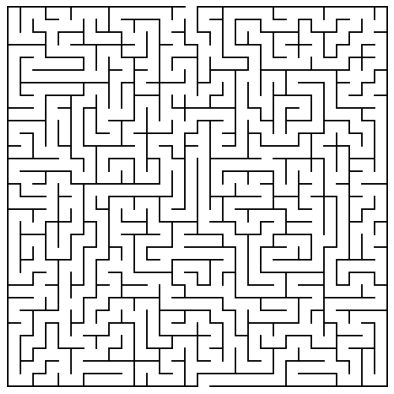

In [5]:
test_image = cv2.imread('task_1/30 by 30 orthogonal maze.png')  # загрузить тестовую картинку
print(test_image[:, :].shape)
plot_one_image(test_image[:, :])

In [6]:
def binary_img_matrix(img):
    new_image = np.array(len(img)*[len(img)*[0]])
    for i in range(len(img)):
        for j in range(len(img[:, 0])):
            if np.array_equal(img[i][j], [0, 0, 0]):
                new_image[i][j] = 0
            else:
                new_image[i][j] = 1
    new_image_1=np.array([new_image[0]])
    for i in range(1, len(new_image[:, 0])):
        if not np.array_equal(new_image[i], new_image[i-1]):
            new_image_1 = np.concatenate((new_image_1, np.array([new_image[i]])), axis = 0)
    new_image_2 = np.array([new_image_1[:, 0]]).T
    for i in range(1, len(new_image_1[0])):
        if not np.array_equal(new_image_1[:, i], new_image_1[:, i-1]):
            new_image_2 = np.concatenate((new_image_2, np.array([new_image_1[:, i]]).T), axis=1)
    return new_image_2
#img = binary_img_matrix(test_image[:, :])
#plot_one_image(img)

In [7]:
def find_way_from_maze(img):
    l = len(img)

    np.set_printoptions(threshold=l**2)

    x0, y0 = (0, 0)

    for i in range(l):
        if img[0][i] == 1:
            y0 = i
            break

    img_numbers = np.zeros_like(img)
    img_numbers[x0][y0] = 1
    stack = [[x0, y0]]
    x, y = (0, 0)
    while len(stack)>0 and x != l-1:
        x, y = stack[len(stack)-1]
        stack.pop()
        for i, j in [[x+1, y], [x, y+1], [x-1, y], [x, y-1]]:
            if -1<i<l and -1<j<l:
                if img[i][j] == 1 and img_numbers[i][j] == 0:
                    stack.append([i, j])
                    img_numbers[i][j] = img_numbers[x][y] + 1
    coords_list = [[y, x]]
    while img_numbers[x][y] != 1:
        for i, j in [[x+1, y], [x, y+1], [x-1, y], [x, y-1]]:
            if -1<i<l and -1<j<l:
                if img_numbers[i][j] == img_numbers[x][y]-1:
                    coords_list.append([j, i])
                    x, y = i, j
    return coords_list
    

In [8]:
way = find_way_from_maze(binary_img_matrix(test_image[:, :]))

[248 480]


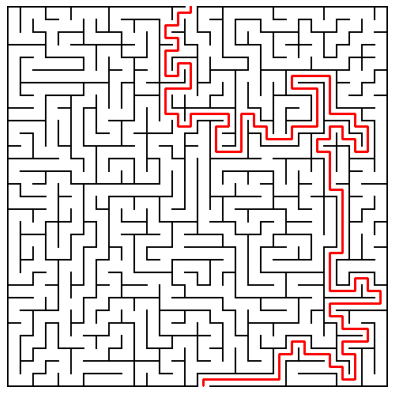

In [9]:
for i in range(1, len(way)):
    cv2.line(test_image[:, :],np.array(way[i-1])*8,np.array(way[i])*8,(255,0,0),2)
plot_one_image(test_image[:, :])
print(np.array(way[0])*8)

Теперь ваша задача реализовать функцию ```plot_maze_path``` в ```task_1.py``` для того, чтобы найти координаты пути через лабиринт.

# Задача №2 - Пробки в городе

Требуется написать программу, которая на вход принимает картинку, на которой схематически изображена машинка на дороге с $N$ полосами и препятствия на полосах. Соответствующие объекты обозначены цветами, которые сохраняются на всех изображениях. 

Результатом работы программы является номер полосы, на которую нужно перестроиться или сообщение о том, что перестраиваться не нужно.

**Примечание: номер дороги считается слева направо, отсчет начинается с нуля.**

Примеры изображений:
<table><tr>
    <td> <img src="https://i.ibb.co/8z84sJG/image_00.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/Z6m4XFz/image_01.jpg" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

In [10]:
from task_2 import find_road_number

(1012, 1098, 3)


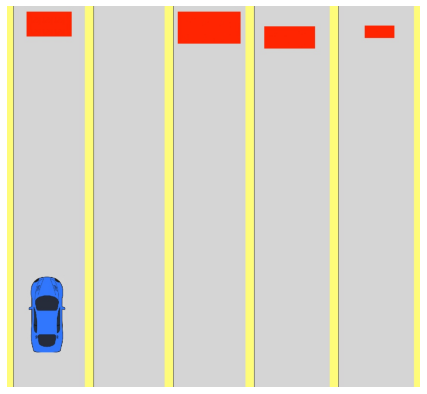

In [48]:
test_image = cv2.imread('task_2/image_00.jpg')
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
plot_one_image(test_image)
color_rec = (255, 37, 1)
color_road = (213, 213, 213)
color_fence = (255, 253, 124)
color_car  = (49, 119, 253)
delta = np.array([1, 1, 1])*20
print(test_image.shape)

In [68]:
car_area = cv2.inRange(test_image, color_car - delta, color_car + delta)
rec_area = cv2.inRange(test_image, color_rec - delta, color_rec + delta)
fence_area = cv2.inRange(test_image, color_fence - delta, color_fence + delta)

E1 = np.array(len(car_area)*[len(car_area)*[1]])

car_area_vision = E1.dot(car_area)
rec_area_vision = E1.dot(rec_area)

rec_area_byn = [1*(i != 0) for i in rec_area_vision[0]]
car_area_byn = [1*(i != 0) for i in car_area_vision[0]]

road_fence =  []
road_line = False

for x in range(len(car_area[0])):
    if (fence_area[0][x] != 255) and road_line == False:
        road_fence.append([x, 0])
        road_line = True
    elif (fence_area[0][x] == 255) and road_line == True:
        road_fence[len(road_fence)-1][1] = x
        road_line = False

        
road_que = len(road_fence)*[0]
for x in range(len(road_fence)):
    if 1 in rec_area_byn[road_fence[x][0]:road_fence[x][1]]:
        road_que[x] = 1
car_que = 0
for x in range(len(road_fence)):
    if 1 in car_area_byn[road_fence[x][0]:road_fence[x][1]]:
        car_que = x
        break

if road_que[car_que] == 0:
    print('Перестраиваться не нужно')
else:
    try:
        road_number = road_que.index(0)
        print(f'Нужно перестроиться на дорогу номер {road_number}')
    except ValueError:
        print('Перестраиваться не нужно')

#road_number = find_road_number(test_image)

#print(f'Нужно перестроиться на дорогу номер {road_number}')

[1, 0, 1, 1, 1]
Нужно перестроиться на дорогу номер 1


# Задача №3 - Аффинные преобразования

## Задача №3.1 - Поверни изображение

Реализуйте функцию, которая поворачивает изображение вокруг заданной точки на заданный угол ($0^\circ-360^\circ$) и преобразует размер изображения, чтобы оно не обрезалось после поворота.

In [13]:
from task_3 import rotate

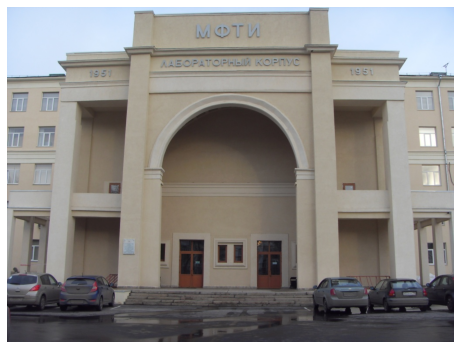

In [14]:
test_image = cv2.imread('task_3/lk.jpg')
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
plot_one_image(test_image)

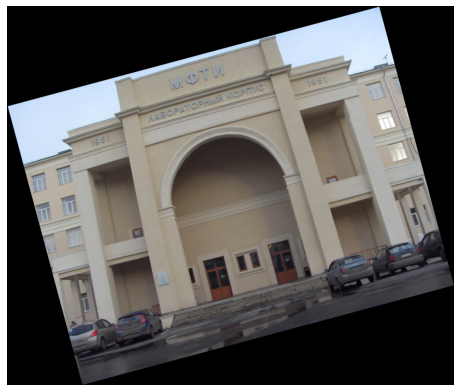

In [22]:
test_point = (200, 200)
test_angle = 15
h, w, _ = test_image.shape
transform_size = [h, w]
shift = [0, 0]

M = cv2.getRotationMatrix2D(test_point, test_angle, scale=1.0)

while True:
    Mshift = np.float32([[1, 0, shift[0]], [0, 1, shift[1]]])
    transformed_image = cv2.warpAffine(test_image, Mshift, transform_size)
    transformed_image = cv2.warpAffine(transformed_image, M, transform_size)
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[0]]) == False):
        shift[1] += w
        transform_size[1] += w
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:,0]]) == False):
        shift[0] += h
        transform_size[0] += h
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[transform_size[1]-1]]) == False):
        transform_size[1] += w
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, transform_size[0]-1]]) == False):
        transform_size[0] += h
        continue
    break
#обрезаем
w1 = 0
w2 = transform_size[1]-1
h1 = 0
h2 = transform_size[0]-1
while True:
    w1 += 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[w1]]) == True):
        continue
    else:
        break
while True:
    w2 -= 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[w2]]) == True):
        continue
    else:
        break
while True:
    h1 += 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, h1]]) == True):
        continue
    else:
        break
while True:
    h2 -= 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, h2]]) == True):
        continue
    else:
        break
transformed_image = transformed_image[w1-1:w2+1, h1-1:h2+1]

plot_one_image(transformed_image)


Проверьте как это должно было получиться

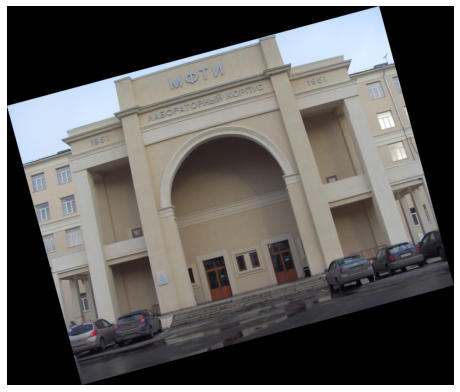

In [16]:
result_image = cv2.imread('task_3/lk_rotate.jpg')
result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
plot_one_image(result_image)

## Задача №3.2 - Афинные преобразования

Реализуйте функцию, которая применяет афинное преобразование между заданными точками на исходном изображении и преобразует размер получившегося изображения, чтобы оно не обрезалось.

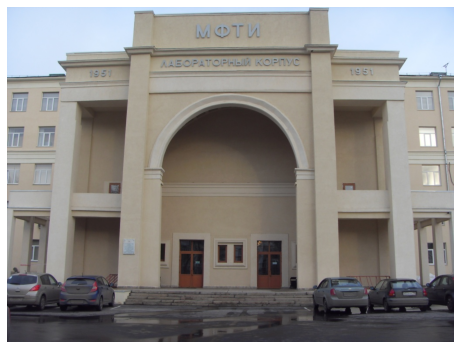

In [17]:
test_image = cv2.imread('task_3/lk.jpg')
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
plot_one_image(test_image)

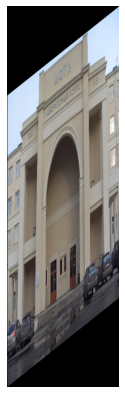

In [18]:
test_point_1 = np.float32([[50, 50], [400, 50], [50, 200]])
test_point_2 = np.float32([[100, 100], [200, 20], [100, 250]]) 

w, h, _ = test_image.shape

M = cv2.getAffineTransform(test_point_1, test_point_2)

transform_size = [h, w]
shift = [0, 0]

#делаем так, чтобы вся новая каринка поместилась в рамки
while True:
    Mshift = np.float32([[1, 0, shift[0]], [0, 1, shift[1]]])
    transformed_image = cv2.warpAffine(test_image, Mshift, transform_size)
    transformed_image = cv2.warpAffine(transformed_image, M, transform_size)
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[0]]) == False):
        shift[1] += w
        transform_size[1] += w
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:,0]]) == False):
        shift[0] += h
        transform_size[0] += h
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[transform_size[1]-1]]) == False):
        transform_size[1] += w
        continue
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, transform_size[0]-1]]) == False):
        transform_size[0] += h
        continue
    break
#обрезаем
w1 = 0
w2 = transform_size[1]-1
h1 = 0
h2 = transform_size[0]-1
while True:
    w1 += 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[w1]]) == True):
        continue
    else:
        break
while True:
    w2 -= 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[w2]]) == True):
        continue
    else:
        break
while True:
    h1 += 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, h1]]) == True):
        continue
    else:
        break
while True:
    h2 -= 1
    if (all([np.array_equal(i, [0, 0, 0]) for i in transformed_image[:, h2]]) == True):
        continue
    else:
        break
transformed_image = transformed_image[w1-1:w2+1, h1-1:h2+1]

plot_one_image(transformed_image)


Проверьте как это должно было получиться

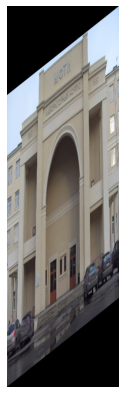

In [19]:
result_image = cv2.imread('task_3/lk_affine.jpg')
result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
plot_one_image(result_image)